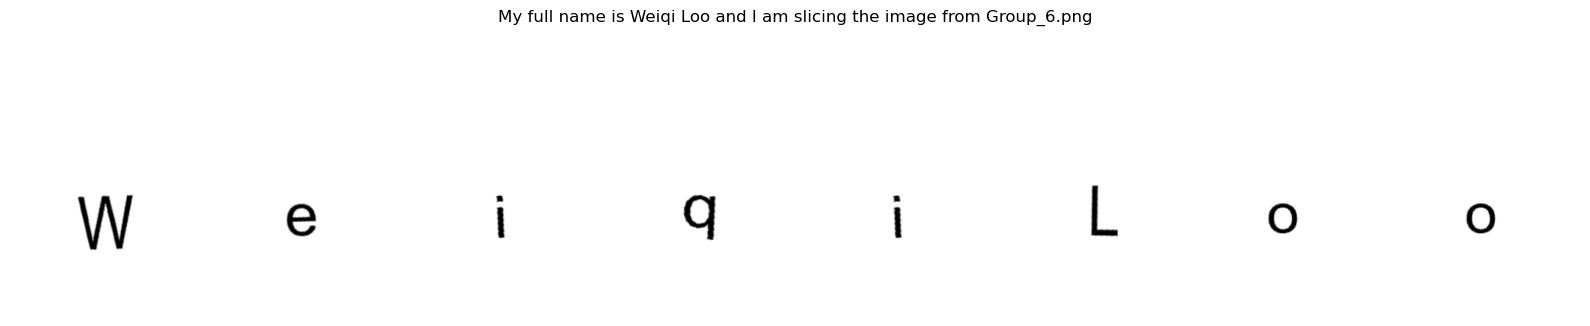

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import rotate, resize

# 1. Load image
# Ensure Group_6.png is in the same directory
img = io.imread('Group_6.png')

# 2. Define Grid coordinates
vcols = [0, 222, 444, 666, 888, 1110, 1332, 1554, 1776, 1998]
hrows = [0, 166, 332, 498, 664, 830, 996]

# 3. Enhanced function to slice, rotate, and resize
def get_letter(row, col, trim=8, angle=0, output_shape=(200, 200)):
    """
    Extracts a letter, rotates it, and resizes it to a specific height/width.
    - output_shape: (height, width) in pixels.
    """
    # Slicing from grid
    letter = img[hrows[row]+trim:hrows[row+1]-trim, 
                 vcols[col]+trim:vcols[col+1]-trim]
    
    # Apply rotation
    # resize=True allows the canvas to expand to fit the rotated corners
    # cval=1.0 assumes the background is white; use 0.0 if background is black
    if angle != 0:
        letter = rotate(letter, angle, resize=True, cval=1.0)
    
    # Adjust Height and Width
    # This standardizes every letter to the same dimensions
    letter_resized = resize(letter, output_shape, anti_aliasing=True)
    
    return letter_resized
    
letters = [
    get_letter(2, 4, angle=337.5, output_shape=(270, 250)),  # W
    get_letter(5, 2, angle=-20,   output_shape=(210, 250)),  # e
    get_letter(1, 0, angle=10,    output_shape=(180, 250)),  # i
    get_letter(3, 7, angle=5,     output_shape=(168, 250)),  # q
    get_letter(1, 0, angle=10,    output_shape=(180, w)),  # i
    get_letter(5, 1, angle=29,    output_shape=(270, w)),  # L
    get_letter(1, 1, angle=207.5, output_shape=(210, w)),  # o
    get_letter(1, 1, angle=207.5, output_shape=(210, w))   # o
]

# 5. Display the result
# figsize (width, height) controls the total size of the plot window
fig, axes = plt.subplots(1, 8, figsize=(16, 4))
fig.suptitle('My full name is Weiqi Loo and I am slicing the image from Group_6.png', fontsize=12)

for ax, letter in zip(axes, letters):
    ax.imshow(letter)
    ax.axis('off')

plt.tight_layout()
plt.show()